In [ ]:
!pip install numpy opencv-python

In [ ]:
import numpy as np
import cv2
import shutil
import os
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import gaussian_filter
from collections import defaultdict
from scipy.spatial.distance import cdist

#Calibrazione Matrice Omografica

In [ ]:
def calibrate_H_Matrix():

      # REAL-WORLD (World) Coordinates in meters (x, y)
      # Assume the origin (0, 0) is the bottom left corner of the court floor.
      # We are using 8 known points for robustness.
      world_points = np.float32([
          [0.0, 20.0], #fondocampo inf sx
          [10.0, 20.0] , #fondocampo inf dx
          [0.0, 17.0], #intersezione linea bianca-plexiglass inf sx
          [5.0, 17.0], #intersezione linee centrale inf
          [10.0, 17.0], #intersezione linea bianca-plexiglass inf dx
          [5.0, 3.0], #intersezione linee centrale sup
          [0, 0], #fondocampo sup sx
          [10.0, 0] #fondocampo sup dx
      ])

      pixel_points = np.float32([
          [214, 950], #fondocampo inf sx
          [1715, 950], #fondocampo inf dx
          [315, 786], #intersezione linea bianca-plexiglass inf sx
          [960, 783], #intersezione linee centrale inf
          [1613, 784], #intersezione linea bianca-plexiglass inf dx
          [960, 371], #intersezione linee centrale sup
          [595, 320], #fondocampo sup sx
          [1326, 318] #fondocampo sup dx
      ])

      # Compute the Homography Matrix (H)

      # cv2.findHomography computes the best H matrix using DLT.
      # RANSAC (cv2.RANSAC) is used as the method to filter noisy points.
      # The 5.0 is the max reprojection error for RANSAC.
      H_matrix, mask = cv2.findHomography(pixel_points,world_points,cv2.RANSAC,5.0)

      return H_matrix

Function to get the players' bounding boxes using tracking


*   player_tracker_v3_pred: this function is a multi-object tracking system designed to reconstruct player movements on a 2D plane, it processes raw computer vision detections, transforms them into real-world coordinates, and maintains player identities across frames.
Its main strength is handling detections gaps, meaning if a player goes temporarily undetected by the system, the function uses momentum-based estimation to predict their location.
It also features automatic rally detection, resetting the tracker if it detects a spatial jump that suggests a video cut.



In [ ]:
def player_tracker_v3_pred(json_path, H_matrix, player_cat_id):

# Attempt to load the JSON file containing the detections
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: JSON file not found at {json_path}")
        return pd.DataFrame(), np.array([])

    # Annotation Preprocessing, creates a dictionary where the key is the frameid and the value all the detections in that frame
    annotations_by_frame = defaultdict(list)

    # Iterates through the JSON, converts the imageid to an integer and checks if each detection matches the target player category id
    for frame_data in data:

        try:
            img_id = int(frame_data.get('image_id', 0))
        except ValueError:
            print(f"Warning: Skipping frame with invalid image_id: {frame_data.get('image_id')}")
            continue

        predictions = frame_data.get('predictions', [])

        # Loop through the predictions within this frame
        for ann in predictions:

            if ann.get('category_id') == player_cat_id:

                bbox = ann.get('bbox')

                # Check for required length (4 elements for a bbox)
                if not isinstance(bbox, list) or len(bbox) != 4:
                     continue # Skip invalid bbox

                # Transforms the pixel coordinates of the player's feet into meter coordinates using the Homography matrix
                bbox_in_meters=compute_contact_point(bbox, H_matrix)
                meter_coord = bbox_in_meters.flatten()

                bbox_y_bottom_m = meter_coord[1]
                bbox_x_bottom_m = meter_coord[0]

                # If a detection is more than 1 meter outside the court boundaries, it is discarded to remove detections like spectators or referees.
                if bbox_y_bottom_m >=-1.0 and bbox_x_bottom_m>=-1.0 and bbox_x_bottom_m<=11.0:

                    annotations_by_frame[img_id].append({'bbox': bbox, 'meter_coord': meter_coord})

    # These dictionaries store the memory of where each player was and how fast they were moving in the previous frame
    last_known_positions = {}
    player_cols = ['Player A1', 'Player A2', 'Player B1', 'Player B2']
    last_velocities = {role: np.array([0.0, 0.0]) for role in player_cols}
    output_rows = []

    # STATISTICS COUNTERS
    total_estimated_points = 0
    total_calculated_points = 0
    # ---------------------------

    sorted_image_ids = sorted(annotations_by_frame.keys())
    total_frames = len(sorted_image_ids)
    CUT_THRESHOLD = 1.0  # Maximum threshold above which the function assumed there has been a cut in the video, menaing a new rally has begun

    for frame_index, image_id in enumerate(tqdm(sorted_image_ids, desc="Tracking Players")): # Progress bar
        current_detections = annotations_by_frame[image_id]

        # --- CUT DETECTION LOGIC ---
        if last_known_positions:
            temp_assignments = assign_by_distance_with_velocity(
                last_known_positions, last_velocities, current_detections
            )

            # Checks if there is a cut in the video, in which case position and momentum memories are resetted
            is_cut = False
            for role, assignment in temp_assignments.items():

                if not assignment.get('is_estimated', False):

                    dist = np.linalg.norm(assignment['meter_coord'] - last_known_positions[role])

                    if dist > CUT_THRESHOLD:

                        is_cut = True
                        break

            if is_cut:

                last_known_positions = {}
                last_velocities = {role: np.array([0.0, 0.0]) for role in player_cols}

        # If no initial positions are in the memory the function looks for the first frame where all 4 players are detected
        # and assigns IDs to each based on their position in the field
        if not last_known_positions:

            if len(current_detections) == 4:

                initial_map = assign_initial_ids(current_detections, COURT_X_SPLIT, COURT_Y_SPLIT)

                if initial_map:

                    last_known_positions = {role: det['meter_coord'] for role, det in initial_map.items()}
                    row = {'Frame Number': image_id}

                    for role in last_known_positions:

                        row[role] = last_known_positions[role]
                        total_calculated_points += 1

                    output_rows.append(row)

            continue

        # Assign IDs to each new detection based on previous postitions and speed, if a detection is missing the function guesses the position of the missing player
        # using memory data
        current_assignments = assign_by_distance_with_velocity(
            last_known_positions, last_velocities, current_detections
        )

        new_positions = {}
        row = {'Frame Number': image_id}

        for role in last_known_positions.keys():

            assignment = current_assignments[role]
            new_pos = np.array(assignment['meter_coord'])
            old_pos = np.array(last_known_positions[role])
            total_calculated_points += 1

            if assignment.get('is_estimated', False):

                total_estimated_points += 1
                last_velocities[role] = last_velocities[role] * 0.95 # Velocity is reduced if the player has not been detected by the system

            else:

                last_velocities[role] = new_pos - old_pos

            new_positions[role] = new_pos
            row[role] = new_pos

        last_known_positions = new_positions
        output_rows.append(row)

    # FINAL DATA PROCESSING
    if not output_rows:

        return pd.DataFrame(), np.array([]), 0.0

    df = pd.DataFrame(output_rows)
    all_points = df[player_cols].values.flatten()
    heatmap_input_array = np.vstack(all_points)

    # Compute percentage of estimated points over detected ones
    estimation_ratio = (total_estimated_points / total_calculated_points) * 100 if total_calculated_points > 0 else 0

    return df, heatmap_input_array, estimation_ratio

##Function to get the ball's bounding box using tracking


*   ball_tracker_v2_pred: this function is a ball tracker designed to reconstruct the 2D path of a ball across a sports court, it processes raw object detections, converts them from pixels to real-world coordinates, and uses a prediction model to handle missing data: if the ball is hidden or the detector fails for a few frames, the function generates a prediction based on the ball's last known velocity and position, ensuring the tracking doesn't simply vanish during high-speed movement or occlusions.

In [ ]:
def ball_tracker_v2_pred(json_path, H_matrix, court_bounds, ball_cat_id):

    # Opens the JSON file containing the model predictions
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Initializes a dictionary to map image_id to its corresponding ball bounding box
    ball_by_frame = {}
    for frame_data in data:

        img_id = frame_data.get('image_id')
        predictions = frame_data.get('predictions', [])

        # Find the ball within the predictions list for this frame
        for pred in predictions:

            if pred.get('category_id') == ball_cat_id:

                ball_by_frame[img_id] = pred.get('bbox')
                break

    if not ball_by_frame:

        print(f"No ball detections found for category_id: {ball_cat_id}")
        return pd.DataFrame(), np.array([]).reshape(0, 2)


    all_ids = sorted(ball_by_frame.keys()) # Gets a chronological list of all frames where the ball was detected
    start_id = min(all_ids)
    end_id = max(all_ids)

    last_pos = None
    velocity = np.array([0.0, 0.0])
    output_rows = []
    X_MIN, X_MAX, Y_MIN, Y_MAX = court_bounds

    # Tracking Loop
    for img_id in range(start_id, end_id + 1):

        bbox = ball_by_frame.get(img_id)
        current_pos = None

        if bbox is not None:

            center_px = np.array([[bbox[0] + bbox[2]/2, bbox[1] + bbox[3]/2]])
            det_pos = pixel_to_world_coordinates(center_px, H_matrix)[0]

            # Check to ensure the projection falls within the court limits
            if X_MIN <= det_pos[0] <= X_MAX and Y_MIN <= det_pos[1] <= Y_MAX:

                current_pos = det_pos

                if last_pos is not None:

                    velocity = current_pos - last_pos

                last_pos = current_pos

        # If the detection is missing or out of bounds it estimates the position using memory data
        if current_pos is None and last_pos is not None:

            pred_pos = last_pos + velocity

            if X_MIN <= pred_pos[0] <= X_MAX and Y_MIN <= pred_pos[1] <= Y_MAX:

                current_pos = pred_pos
                velocity *= 0.98
                last_pos = current_pos

            else:

                last_pos = None
                velocity = np.array([0.0, 0.0])

        output_rows.append({'Frame Number': img_id, 'Ball_Coords': current_pos})

    df = pd.DataFrame(output_rows)
    valid_coords = df['Ball_Coords'].dropna().tolist()
    heatmap_array = np.vstack(valid_coords) if valid_coords else np.array([]).reshape(0, 2)

    return df, heatmap_array


#Function to generate the Heatmap

In [ ]:
def generate_player_heatmap(input_array, court_dimensions):

    min_x, max_x, min_y, max_y = court_dimensions

    x_bins = 100
    y_bins = 200

    world_x_coords = input_array[:, 0]
    world_y_coords = input_array[:, 1]

    # Standard variant
    H, x_grid, y_grid = np.histogram2d(
        world_x_coords,
        world_y_coords,
        bins=[x_bins, y_bins],
        range=[[min_x, max_x], [min_y, max_y]]
    )

    # Transpose H so X is horizontal and Y is vertical for plotting
    H = H.T
    H_min = H.min()
    H_max = H.max()

    if H_max == 0:
        # Case 1: All values are zero (no data points landed in the bins)
        # Set all normalized values to zero
        H_normalized = np.zeros_like(H)

    elif H_max == H_min:
        # Case 2: All values are non-zero but identical (H_max = H_min > 0)
        # Set all normalized values to one
        H_normalized = np.ones_like(H)

    else:
        # Case 3: Standard normalization (H_max > H_min)
        H_normalized = (H - H_min) / (H_max - H_min)

    #Smoothing for visual
    H_smoothed = gaussian_filter(H_normalized, sigma=1.5)

    fig, ax = plt.subplots(figsize=(8, 16))

    im = ax.pcolormesh(x_grid, y_grid, H_smoothed, cmap='jet', shading='auto')


    ax.hlines([0.0, 3.0, 10.0, 17.0, 20.0], 0.0, 10.0, colors='gray', linestyles='-') # Filed lines
    ax.vlines(5.0, 3.0, 17.0, colors='gray', linestyles='-')
    ax.vlines([0.0, 10.0], 0.0, 20.0, colors='gray', linestyles='-') # Center line

    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)

    ax.set_title(f'Player Movement Heatmap ({x_bins}x{y_bins} Resolution)')
    ax.set_xlabel('Court X Position (meters)')
    ax.set_ylabel('Court Y Position (meters)')
    ax.axis('equal')
    fig.colorbar(im, ax=ax, label='Time Spent (Density)')
    plt.show()

#Function to generate the Bird-Eye View of a single rally (BEV)

In [ ]:
def generate_bev_frames(player_df, ball_df, FOLDER_NAME="snapshots"):

    # Checks if there exists alrady a folder, in which case it deletes it and creates a new one
    if os.path.exists(FOLDER_NAME):

        print(f"Cleaning existing folder: {FOLDER_NAME}...")
        shutil.rmtree(FOLDER_NAME)

    os.makedirs(FOLDER_NAME)

    # Creates a dictionary for the ball positions making the script much faster compared to searching a DataFrame
    ball_lookup = dict(zip(ball_df['Frame Number'], ball_df['Ball_Coords']))
    player_cols = ['Player A1', 'Player A2', 'Player B1', 'Player B2']

    # Process all the frames
    for i in range(len(player_df)):

        row = player_df.iloc[i]
        frame_id = i
        actual_img_id = row['Frame Number']

        fig, ax = plt.subplots(figsize=(8, 10))
        draw_padel_court(ax)

        # Plot all last 5 positions of the ball, this adds a "comet tail" effect for better visibility
        for j in range(max(0, i-5), i):

            prev_frame = player_df.iloc[j]['Frame Number']
            prev_ball = ball_lookup.get(prev_frame)

            if prev_ball is not None:

                alpha = (j - (i-5)) / 5  # Fades out older points
                ax.scatter(prev_ball[0], prev_ball[1], color='yellow', s=40, alpha=alpha, zorder=4)

        # Plot current players
        for col in player_cols:

            pos = row[col]

            if pos is not None and not np.any(np.isnan(pos)):

                color = 'blue' if 'A' in col else 'red'
                ax.scatter(pos[0], pos[1], color=color, s=150, edgecolors='white', zorder=3)
                ax.text(pos[0]+0.2, pos[1]+0.2, col, fontsize=8, fontweight='bold')

        # Plot current ball
        ball_pos = ball_lookup.get(actual_img_id)
        if ball_pos is not None and not np.any(np.isnan(ball_pos)):

            ax.scatter(ball_pos[0], ball_pos[1], color='yellow', s=120, edgecolors='black', zorder=5)

        ax.set_title(f"BEV - Frame {actual_img_id}")

        # Save with leading zeros so FFmpeg sorts them correctly
        plt.savefig(f"{FOLDER_NAME}/frame_{frame_id:06d}.png")
        plt.close(fig)

    print(f"Done! {len(player_df)} frames generated in /{FOLDER_NAME}")

#Function to compute the average distance between players

In [ ]:
def compute_team_distances(df):
    dist_df = pd.DataFrame(index=df.index)
    dist_df['Frame Number'] = df['Frame Number']

    # Calculate for Team A
    dist_A, h_dist_A = get_dist(df['Player A1'], df['Player A2'])
    dist_df['Team A Total Dist'] = dist_A
    dist_df['Team A Horizontal Dist'] = h_dist_A

    # Calculate for Team B
    dist_B, h_dist_B = get_dist(df['Player B1'], df['Player B2'])
    dist_df['Team B Total Dist'] = dist_B
    dist_df['Team B Horizontal Dist'] = h_dist_B

    return dist_df

#Auxiliary Functions

*   assign_initial_ids: this function sets the identities of the players at the very beginning of a rally, it takes four anonymous detections and, by splitting the court into quadrants, decides which detection is Player A1, A2, B1, or B2.
*   assign_by_distance_with_velocity: this is the tracking logic used for every frame after initialization, it uses linear prediction (position + velocity) to guess where a player should be, then matches those guesses to the closest actual detections found by YOLO
*   pixel_to_world_coordinates: this function performs the Homography transformation taking 2D coordinates from a video frame (pixels) and maps them onto a flat 2D plane (meters) based on the court calibration
*   compute_contact_point: this function takes the input bbox in the format (x_topleft, y_topleft, hight, width) and tranforms it into (x_center, y_bottom) which is the contact point between tha player and the terrain
*   get_dist: computes the total nad horizontal distance in meters betwen two given players
*   extract_subpart_json: this function extracts a subportion of the JSON file based on the starting and ending imageid
*   draw_padel_court: draws the padel court for the BEV output

In [ ]:

def assign_initial_ids(current_detections, x_split, y_split):

    # Structure to hold the final assignments
    initial_assignments = {}

    # Split detections into Team halves based on Y-split
    team_a_detections = []
    team_b_detections = []

    for det in current_detections:
        meter_y = det['meter_coord'][1]

        if meter_y <= y_split:
            team_b_detections.append(det) # Back half
        else:
            team_a_detections.append(det) # Front half

    # Ensure a 2-2 split for stable initial assignment
    if len(team_a_detections) != 2 or len(team_b_detections) != 2:

        return {}

    # Sort by X-coordinate within each half
    team_b_detections.sort(key=lambda d: d['meter_coord'][0])
    team_a_detections.sort(key=lambda d: d['meter_coord'][0])

    # Final role assignment

    # Team B
    initial_assignments['Player B1'] = team_b_detections[0]
    initial_assignments['Player B2'] = team_b_detections[1]

    # Team A
    initial_assignments['Player A1'] = team_a_detections[0]
    initial_assignments['Player A2'] = team_a_detections[1]

    return initial_assignments

#-------------------------------------------------------------------------------

def assign_by_distance_with_velocity(last_pos_dict, last_vel_dict, current_dets):


    old_ids = sorted(last_pos_dict.keys())

    last_pos_arr = np.array([last_pos_dict[rid] for rid in old_ids])
    last_vel_arr = np.array([last_vel_dict[rid] for rid in old_ids])

    # P_predicted = P_last + V
    predicted_coords = last_pos_arr + last_vel_arr

    # Skip for empty frames
    if not current_dets:
        return {
            role: {'meter_coord': predicted_coords[i], 'is_estimated': True}
            for i, role in enumerate(old_ids)
        }

    # New detections
    new_coords = np.array([d['meter_coord'] for d in current_dets])

    # Computes a 4xN matrix containing the distance between every predicted player and every new detection
    dist_matrix = cdist(predicted_coords, new_coords, metric='euclidean')

    assigned_roles = {}
    matched_old_idx = set()

    # Implements a greedy match, meaning it finds the smallest distance in the matrix and pairs that player with that detection
    num_matches = min(len(old_ids), len(current_dets))
    for _ in range(num_matches):

        min_idx = np.argmin(dist_matrix)
        old_idx, new_idx = np.unravel_index(min_idx, dist_matrix.shape)

        # If the best remaining match is 'infinity', stop matching
        if dist_matrix[old_idx, new_idx] == np.inf:
            break

        role = old_ids[old_idx]
        assigned_roles[role] = {
            'meter_coord': current_dets[new_idx]['meter_coord'],
            'is_estimated': False
        }
        matched_old_idx.add(old_idx)

        # Eliminate row and column from future consideration
        dist_matrix[old_idx, :] = np.inf
        dist_matrix[:, new_idx] = np.inf

    # For any player who didn't find a matching detection, the function assigns the predicted position and sets is_estimated to True
    for i, role in enumerate(old_ids):

        if i not in matched_old_idx:

            assigned_roles[role] = {
                'meter_coord': predicted_coords[i],
                'is_estimated': True
            }

    return assigned_roles


# ------------------------------------------------------------------------------

def pixel_to_world_coordinates(pixel_coords_N_2, H_matrix):

    N = pixel_coords_N_2.shape[0]

    # Reshapes the input list of points into a 3D array (N, 1, 2) as this specific shape is required by OpenCV's math functions
    pixel_coords_reshaped = pixel_coords_N_2.reshape(N, 1, 2).astype(np.float32)

    # This function uses the H_matrix to perform the perspective transformation
    world_coords_np = cv2.perspectiveTransform(pixel_coords_reshaped, H_matrix)

    # Reshape output back to (N, 2)
    final_world_coords_N_2 = world_coords_np.reshape(-1, 2)

    return final_world_coords_N_2

# ------------------------------------------------------------------------------

def compute_contact_point(bbox, H_matrix):

    bbox_x_center = bbox[0] + bbox[2] / 2
    bbox_y_bottom = bbox[1] + bbox[3]

    contact_point_coord_pixels = np.array([[bbox_x_center, bbox_y_bottom]], dtype=np.float32)

    contact_point_coord_meters = pixel_to_world_coordinates(contact_point_coord_pixels, H_matrix)

    return contact_point_coord_meters;

# ------------------------------------------------------------------------------

def get_dist(p1_coords, p2_coords):

        p1 = np.vstack(p1_coords)
        p2 = np.vstack(p2_coords)

        total_dist = np.sqrt(np.sum((p1 - p2)**2, axis=1))

        horiz_dist = np.abs(p1[:, 0] - p2[:, 0])

        return total_dist, horiz_dist

# ------------------------------------------------------------------------------

def extract_subpart_json(input_path, output_path, start_id, end_id):

    try:
        with open(input_path, 'r') as f:
            data = json.load(f)

        if isinstance(data, list):
            filtered_data = [
                frame for frame in data
                if start_id <= int(frame.get('image_id', -1)) <= end_id
            ]
            count = len(filtered_data)

        elif isinstance(data, dict):
            filtered_data = data.copy()

            if 'annotations' in data:

                filtered_data['annotations'] = [
                    ann for ann in data['annotations']
                    if start_id <= int(ann.get('image_id', -1)) <= end_id
                ]

                count = len(filtered_data['annotations'])

            if 'images' in data:

                filtered_data['images'] = [
                    img for img in data['images']
                    if start_id <= int(img.get('id', img.get('image_id', -1))) <= end_id
                ]

        else:

            raise ValueError("Input JSON is neither a list nor a dictionary.")

        with open(output_path, 'w') as f:
            json.dump(filtered_data, f)

        print(f"Success: {input_path} -> {output_path}")
        print(f"Kept {count} entries in range {start_id} to {end_id}.")

    except Exception as e:
        print(f"Error processing {input_path}: {e}")

# ------------------------------------------------------------------------------

def draw_padel_court(ax):

    court_boundary = patches.Rectangle((0, 0), 10, 20, linewidth=2, edgecolor='black', facecolor='none', zorder=1)
    ax.add_patch(court_boundary)

    # The Net (at Y = 10m)
    ax.hlines(10, 0, 10, colors='black', linewidth=3, zorder=2, label='Net')

    # Service Lines (6.95m from the net)
    ax.hlines([3, 17], 0, 10, colors='black', linewidth=1.5, linestyles='-', zorder=1)

    # Center Service Line (Connects service lines to back walls)
    ax.vlines(5.0, 3.0, 17.0, colors='black', linewidth=1.5, zorder=1)

    # Outer Walls
    ax.vlines([0, 10], 0, 20, colors='black', linewidth=2, zorder=1)

    ax.set_xlim(-1, 11)
    ax.set_ylim(-1, 21)
    ax.set_aspect('equal')
    ax.axis('off')

#Blocco di esecuzione

In [ ]:
#GET SINGLE GAME
extract_subpart_json('predictions/predictionsF.json', 'first_game_females.json', 0, 3415) # Get a full game to compute heatmap
extract_subpart_json('predictions/predictionsF.json', 'single_rally_females.json', 495, 829) # Get a single rally to comput BEV video

Success: predictionsF.json -> first_game_females.json
Kept 3416 entries in range 0 to 3415.
Success: predictionsF.json -> single_rally_females.json
Kept 335 entries in range 495 to 829.


Tracking Players: 100%|██████████| 3416/3416 [00:00<00:00, 6332.23it/s]


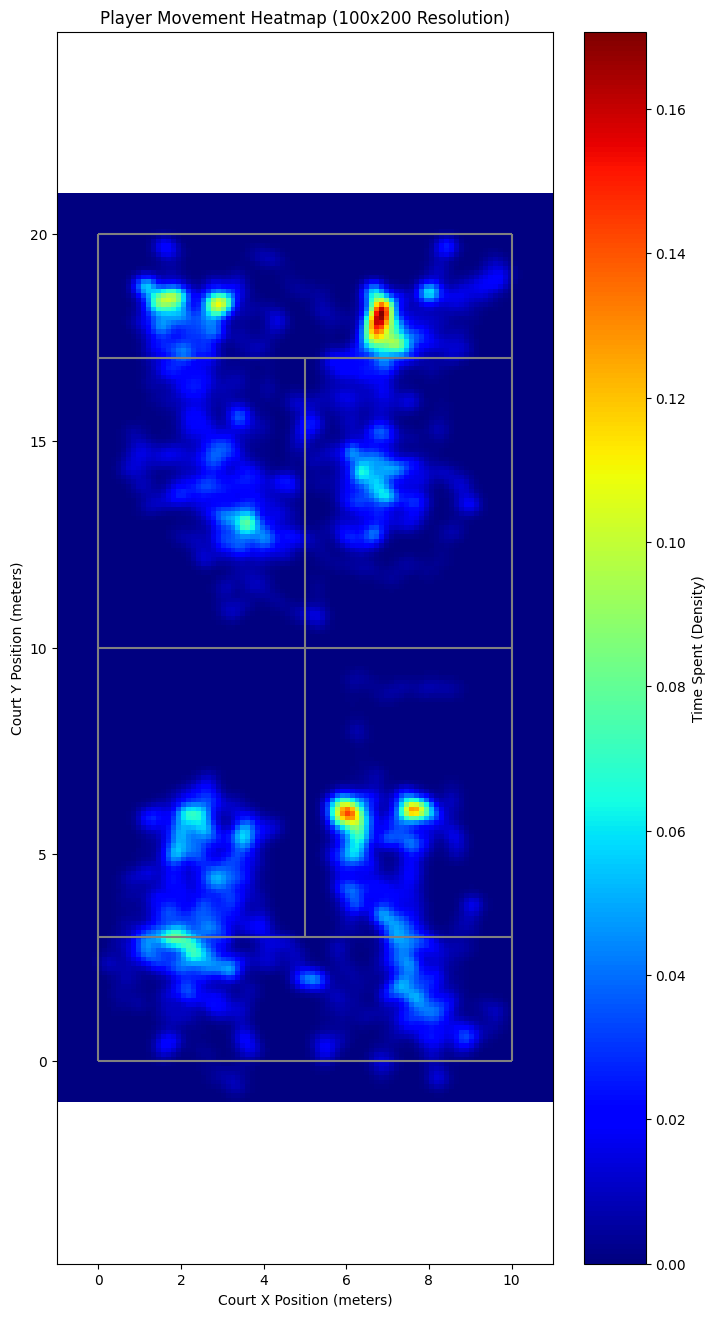

Avg Team A Total Dist: 4.85 meters
Avg Team A Horizontal Dist: 4.19 meters
Avg Team B Total Dist: 5.04 meters
Avg Team B Horizontal Dist: 4.58 meters


In [ ]:
# CONFIGURATION

JSON_PATH_HEATMAP = 'first_game_females.json'
JSON_PATH_BEV = 'single_rally_females.json'

PLAYER_CATEGORY_ID = 0
BALL_CATEGORY_ID = 32

COURT_BOUNDS = (-1.0, 11.0, -1.0, 21.0)
COURT_X_SPLIT = 5.0
COURT_Y_SPLIT = 10.0

FOLDER_NAME = "BEV_frames"

tracking_table = pd.DataFrame()
tracking_table_ball = pd.DataFrame()


#GET HOMOGRAPHY MATRIX

H_matrix=calibrate_H_Matrix()


#GET BBOXES

tracking_table, bboxes_array, estimation_ratio = player_tracker_v3_pred(JSON_PATH_HEATMAP,H_matrix,PLAYER_CATEGORY_ID)


#GENERATE HEATMAP

#print(f"Estimation Ratio: {estimation_ratio}")
generate_player_heatmap(bboxes_array, COURT_BOUNDS)


#COMPUTE AVG DISTANCE

if not tracking_table.empty:

  distance_table = compute_team_distances(tracking_table)

  # Calculate Averages
  metrics = [
      'Team A Total Dist', 'Team A Horizontal Dist',
      'Team B Total Dist', 'Team B Horizontal Dist'
  ]

  for m in metrics:
      avg = distance_table[m].mean()
      print(f"Avg {m}: {avg:.2f} meters")


In [ ]:
#GET BBOXES

tracking_table, bboxes_array, estimation_ratio = player_tracker_v3_pred(JSON_PATH_BEV,H_matrix,PLAYER_CATEGORY_ID)

tracking_table_ball, bboxes_array_ball = ball_tracker_v2_pred(JSON_PATH_BEV,H_matrix,COURT_BOUNDS, BALL_CATEGORY_ID)

#CREATE BIRDS-EYE VIEW VIDEO

generate_bev_frames(tracking_table, tracking_table_ball, FOLDER_NAME)
print("Frames generated. Ready for video compilation.")

Tracking Players: 100%|██████████| 335/335 [00:00<00:00, 7409.30it/s]


Done! 335 frames generated in /BEV_frames
Frames generated. Ready for video compilation.


In [ ]:
#Run to obtain the video from the frames

!ffmpeg -y -framerate 30 -i BEV_frames/frame_%06d.png -c:v libx264 -pix_fmt yuv420p output_bev.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab